In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,f1_score,accuracy_score,roc_auc_score,precision_score,recall_score

In [2]:
df=pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\SVM\product_sales_dataset_final.csv")
df

,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,199996,08-15-23,William Jackson,Boston,Massachusetts,East,United States,Home & Furniture,Storage,Storage Rack,4,254.42,1017.68,334.72
199996,199997,10-17-23,Sharon Ferrell,Bismarck,North Dakota,Centre,United States,Accessories,Small Electronics,Charging Cable,1,237.04,237.04,46.53
199997,199998,12-03-23,Katie Rivera,Santa Fe,New Mexico,West,United States,Accessories,Wearable Accessories,Sunglasses,2,106.83,213.66,102.57
199998,199999,12-08-23,Lisa Sullivan,New York City,New York,East,United States,Clothing & Apparel,Women's Wear,Zara Blouse,2,353.01,706.02,288.74


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       200000 non-null  int64  
 1   Order_Date     200000 non-null  str    
 2   Customer_Name  200000 non-null  str    
 3   City           200000 non-null  str    
 4   State          200000 non-null  str    
 5   Region         200000 non-null  str    
 6   Country        200000 non-null  str    
 7   Category       200000 non-null  str    
 8   Sub_Category   200000 non-null  str    
 9   Product_Name   200000 non-null  str    
 10  Quantity       200000 non-null  int64  
 11   Unit_Price    200000 non-null  float64
 12   Revenue       200000 non-null  float64
 13   Profit        200000 non-null  float64
dtypes: float64(3), int64(2), str(9)
memory usage: 21.4 MB


In [4]:
df.isnull().sum()
df.columns=df.columns.str.strip()
df.columns=df.columns.str.lower()

In [5]:
# Check for duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(0)

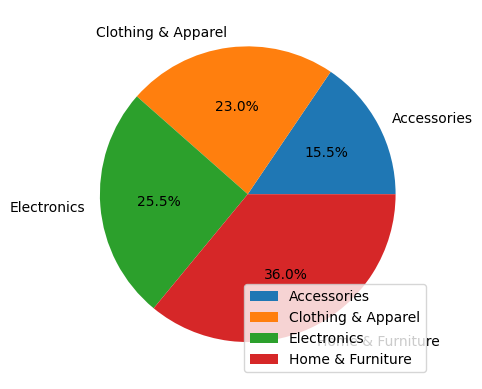

In [6]:
# Plot the distribution of average profit across product categories
df.groupby('category')['profit'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')
plt.show()

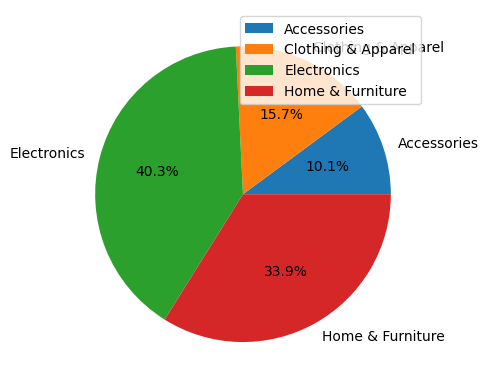

In [7]:
# Plot the distribution of average revenue across product categories
df.groupby('category')['revenue'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')
plt.show()

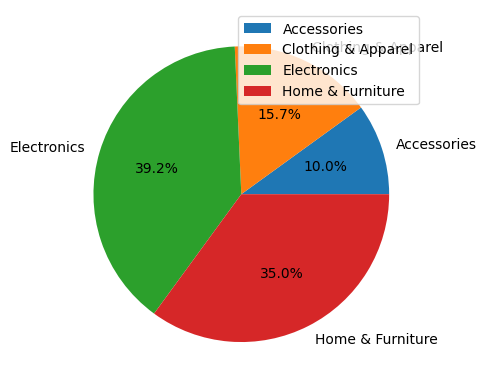

In [8]:
# Plot the distribution of average unit price across product categories
df.groupby('category')['unit_price'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')
plt.show()

In [9]:
# Calculate and print the variance for all numerical features to understand discriminative power
for i in df.select_dtypes(include='number').columns:
  print(i,np.var(df[i]))

order_id 3333333333.25
quantity 1.2111740000000002
unit_price 76656.74350116926
revenue 551261.254982193
profit 24239.12451757595


In [10]:
# Convert 'order_date' column to datetime objects
df['order_date']=pd.to_datetime(df['order_date'])

C:\Users\HP\AppData\Local\Temp\ipykernel_9252\2962252389.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date']=pd.to_datetime(df['order_date'])


In [11]:
# Extract the month from the 'order_date' and create a new 'order_month' column
df['order_month']=df['order_date'].dt.month

In [12]:
# Calculate 'cost_price' based on revenue, profit, and quantity
df['cost_price']=(df['revenue']-df['profit'])/df['quantity']

<Axes: xlabel='order_month', ylabel='profit'>

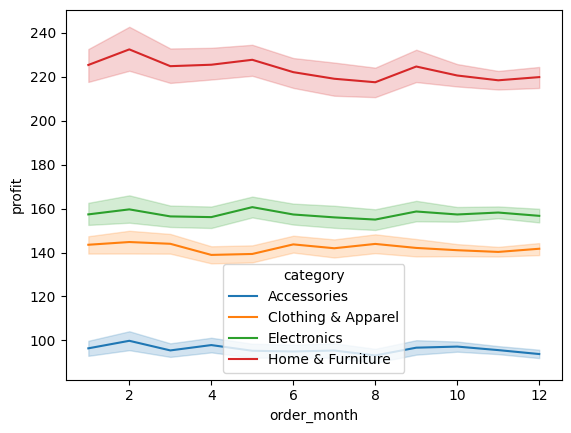

In [13]:
import seaborn as sns
# Plot profit trends over months for each category
sns.lineplot(data=df,x='order_month',y='profit', hue='category')

<Axes: xlabel='order_month', ylabel='revenue'>

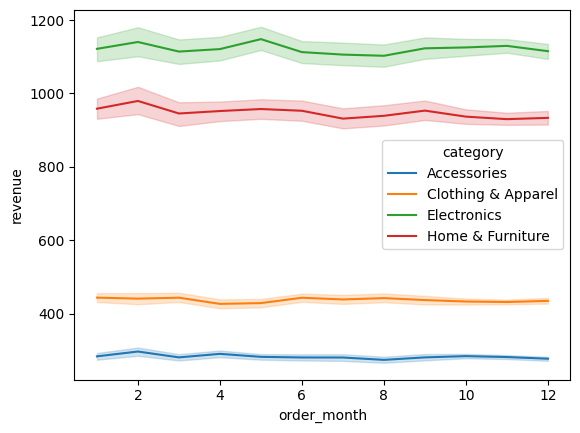

In [14]:
# Plot revenue trends over months for each category
sns.lineplot(data=df,x='order_month',y='revenue', hue='category')

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   order_id       200000 non-null  int64         
 1   order_date     200000 non-null  datetime64[us]
 2   customer_name  200000 non-null  str           
 3   city           200000 non-null  str           
 4   state          200000 non-null  str           
 5   region         200000 non-null  str           
 6   country        200000 non-null  str           
 7   category       200000 non-null  str           
 8   sub_category   200000 non-null  str           
 9   product_name   200000 non-null  str           
 10  quantity       200000 non-null  int64         
 11  unit_price     200000 non-null  float64       
 12  revenue        200000 non-null  float64       
 13  profit         200000 non-null  float64       
 14  order_month    200000 non-null  int32         
 15  cost_price 

In [16]:
df.isnull().sum()

order_id         0
order_date       0
customer_name    0
city             0
state            0
region           0
country          0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
revenue          0
profit           0
order_month      0
cost_price       0
dtype: int64

<Axes: >

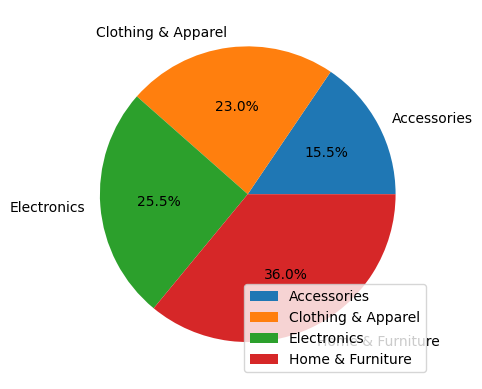

In [17]:
# Plot the distribution of average profit across product categories
df.groupby('category')['profit'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')

<Axes: >

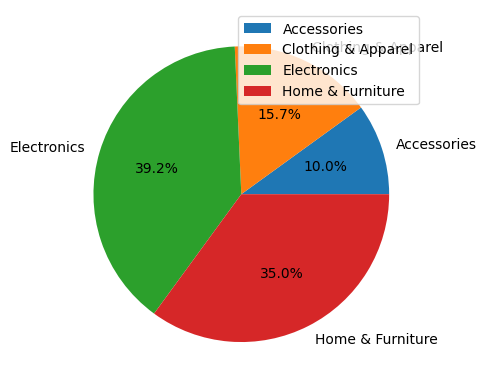

In [18]:
df.groupby('category')['unit_price'].mean().plot(kind='pie',legend=True,autopct='%1.1f%%')

What insights from EDA indicate that category prediction is feasible?

In [19]:
# 1 Checkbalance Balance 

df['category'].value_counts()

category
Clothing & Apparel    62298
Electronics           51230
Home & Furniture      50564
Accessories           35908
Name: count, dtype: int64

In [20]:
# 2 Balance data set
df_ele=df[df['category']=='Electronics'].sample(20000,random_state=42)
df_cloth=df[df['category']=='Clothing & Apparel'].sample(20000,random_state=42)
df_home=df[df['category']=='Home & Furniture'].sample(20000,random_state=42)
df_acc=df[df['category']=='Accessories'].sample(20000,random_state=42)

df_new=pd.concat([df_ele,df_cloth,df_home,df_acc])
df_new=df_new.sample(frac=1,random_state=42)

print(df_new['category'].value_counts())


category
Home & Furniture      20000
Accessories           20000
Electronics           20000
Clothing & Apparel    20000
Name: count, dtype: int64


In [21]:
df_new.columns=df_new.columns.str.strip().str.lower()

In [22]:
df_new

,order_id,order_date,customer_name,city,state,region,country,category,sub_category,product_name,quantity,unit_price,revenue,profit,order_month,cost_price
25444,25445,2023-11-09,Michael Wilson,Chandler,Arizona,West,United States,Home & Furniture,Furniture,Office Chair,1,368.11,368.11,79.30,11,288.8100
16100,16101,2024-05-14,Max Franklin,Lincoln,Nebraska,Centre,United States,Home & Furniture,Home Decor,Throw Pillows,3,312.29,936.87,211.26,5,241.8700
181814,181815,2023-06-29,Melanie Simpson,Dallas,Texas,South,United States,Accessories,Bags,Wallet,2,70.10,140.20,26.20,6,57.0000
82760,82761,2023-11-13,Jeffrey Hill,Mesa,Arizona,West,United States,Accessories,Bags,Wallet,1,200.72,200.72,38.85,11,161.8700
27394,27395,2023-06-30,Luis Gordon,Colorado Springs,Colorado,West,United States,Home & Furniture,Kitchenware,Cookware Set,5,853.00,4265.00,672.23,6,718.5540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111967,111968,2023-01-22,Tammy Mcdowell,Austin,Texas,South,United States,Electronics,Wearables,Apple Watch,6,934.78,5608.68,614.91,1,832.2950
123396,123397,2024-05-04,Julie Christensen,Chandler,Arizona,West,United States,Home & Furniture,Bedding,Tempur-Pedic Mattress,4,880.13,3520.52,1042.17,5,619.5875
89201,89202,2024-05-29,Laura Turner,Albuquerque,New Mexico,West,United States,Accessories,Bags,Tote Bag,2,95.76,191.52,55.88,5,67.8200
103621,103622,2023-06-29,Ashley Lewis,Pittsburgh,Pennsylvania,East,United States,Electronics,Laptops,Dell XPS 13,1,694.87,694.87,69.25,6,625.6200


In [23]:
df_new['unit_price'] = df_new['revenue'] / df_new['quantity']

In [26]:
margin_map = {
    "Electronics": 0.15,          # 15%
    "Clothing & Apparel": 0.60,   # 60%
    "Home & Furniture": 0.35,     # 35%
    "Accessories": 0.50           # 50%
}

In [27]:
df_new["purchase_price"] = df_new.apply(
    lambda row: row["unit_price"] * (1 - margin_map[row["category"]]),
    axis=1
)

In [ ]:
# df_new["purchase_price"] = df_new["unit_price"] * 0.6   # fixed 40% margin for all

# df_new["revenue"] = df_new["quantity"] * df_new["unit_price"]

# df_new["profit"] = df_new["revenue"] - (df_new["quantity"] * df_new["purchase_price"])


In [28]:
df_new["revenue"] = df_new["quantity"] * df_new["unit_price"]
df_new["profit"] = df_new["revenue"] - (df_new["quantity"] * df_new["purchase_price"])

In [29]:
df_new.head()

,order_id,order_date,customer_name,city,state,region,country,category,sub_category,product_name,quantity,unit_price,revenue,profit,order_month,cost_price,purchase_price
25444,25445,2023-11-09,Michael Wilson,Chandler,Arizona,West,United States,Home & Furniture,Furniture,Office Chair,1,368.11,368.11,128.8385,11,288.810,239.2715
16100,16101,2024-05-14,Max Franklin,Lincoln,Nebraska,Centre,United States,Home & Furniture,Home Decor,Throw Pillows,3,312.29,936.87,327.9045,5,241.870,202.9885
181814,181815,2023-06-29,Melanie Simpson,Dallas,Texas,South,United States,Accessories,Bags,Wallet,2,70.10,140.20,70.1000,6,57.000,35.0500
82760,82761,2023-11-13,Jeffrey Hill,Mesa,Arizona,West,United States,Accessories,Bags,Wallet,1,200.72,200.72,100.3600,11,161.870,100.3600
27394,27395,2023-06-30,Luis Gordon,Colorado Springs,Colorado,West,United States,Home & Furniture,Kitchenware,Cookware Set,5,853.00,4265.00,1492.7500,6,718.554,554.4500


In [30]:
# 3. FEATURES & TARGET

X = df_new[['quantity', 'unit_price', 'purchase_price' ,'revenue', 'profit']]
y = df_new['category']

In [31]:
# 4. ENCODING

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [32]:
# 5. SCALING (MANDATORY FOR SVM)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42
)

In [34]:
# 7. MODEL TRAINING

from sklearn.svm import SVC

model = SVC(
    kernel='rbf',
    C=10,
    gamma=0.1,
    class_weight='balanced',
    probability=True
)

model.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [35]:
# 8. EVALUATION

from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9999375
Confusion matrix:
 [[4008    0    0    0]
 [   0 3934    0    0]
 [   0    0 3982    0]
 [   1    0    0 4075]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4008
           1       1.00      1.00      1.00      3934
           2       1.00      1.00      1.00      3982
           3       1.00      1.00      1.00      4076

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000



In [36]:
# 9. save model
import joblib

joblib.dump(model, "svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model, scaler, encoder saved successfully")

Model, scaler, encoder saved successfully
